In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

alpha_true = 0.01  # thermische Diffusivität
n_points = 200
sigma = 0.01

# Analytische Lösung — zum Vergleichen
def u_exact(x, y, t):
    return np.exp(-2 * alpha_true * np.pi**2 * t) * np.sin(np.pi * x) * np.sin(np.pi * y)

# Deine Aufgabe:
# 1. Erzeuge 200 zufällige Datenpunkte (x,y,t) im Raum [0,1]×[0,1]×[0,1]
x_rand = np.random.rand(n_points, 1)
y_rand = np.random.rand(n_points, 1)
t_rand = np.random.rand(n_points, 1)

# 2. Berechne u_exact an diesen Punkten
u_vals = u_exact(x=x_rand, y=y_rand, t=t_rand)

# 3. Füge Rauschen hinzu (sigma=0.01)
# (Normalverteilt mit Mittelwert 0 und Standardabweichung sigma)
noise = np.random.normal(0, sigma, u_vals.shape)
u_noisy = u_vals + noise

# 4. Konvertiere alles in PyTorch Tensoren
# Wir nutzen float32, da dies der Standard für neuronale Netze in PyTorch ist

# Matrix (x,y,t) — das ist gut für den Datenteil. 
# Für den Physics Loss brauchst du x, y, t separat damit autograd nach jeder Variable einzeln ableiten kann.
x_data = torch.tensor(x_rand, dtype=torch.float).reshape(-1, 1).to(device)
y_data = torch.tensor(y_rand, dtype=torch.float).reshape(-1, 1).to(device)
t_data = torch.tensor(t_rand, dtype=torch.float).reshape(-1, 1).to(device)

X_train = torch.tensor(np.hstack((x_rand, y_rand, t_rand)), dtype=torch.float32).to(device)
u_train = torch.tensor(u_noisy, dtype=torch.float32).reshape(-1, 1).to(device)



print("\nErste 5 Punkte (x,y,t) -> u_noisy")
for i in range(5):
    print(f"{X_train[i].tolist()} -> {u_train[i].item():.4f}")




Erste 5 Punkte (x,y,t) -> u_noisy
[0.714597225189209, 0.5201556086540222, 0.912475049495697] -> 0.6511
[0.8656269907951355, 0.11173347383737564, 0.41350674629211426] -> 0.1260
[0.972883403301239, 0.423686683177948, 0.8037746548652649] -> 0.0602
[0.023605985566973686, 0.4172903001308441, 0.20079505443572998] -> 0.0645
[0.5497134923934937, 0.7964471578598022, 0.38151609897613525] -> 0.5470


In [13]:
import torch.nn as nn

class PINN2D(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.l1 = nn.Linear(3, hidden)
        self.l2 = nn.Linear(hidden, hidden)
        self.l3 = nn.Linear(hidden, 1)
        self.act = nn.Tanh()
        nn.init.xavier_uniform_(self.l1.weight); nn.init.zeros_(self.l1.bias)
        nn.init.xavier_uniform_(self.l2.weight); nn.init.zeros_(self.l2.bias)
        nn.init.xavier_uniform_(self.l3.weight); nn.init.zeros_(self.l3.bias)

    def forward(self, x):
        x = self.act(self.l1(x))
        x = self.act(self.l2(x))
        out = self.l3(x)
        return out

model = PINN2D().to(device)
print(f"Parameter im Netz: {sum(p.numel() for p in model.parameters())}")


Parameter im Netz: 4481


In [14]:
mse = nn.MSELoss()

def physics_loss(model, x_col, y_col, t_col, alpha):
    x = x_col.clone().detach().requires_grad_(True).to(device)
    y = y_col.clone().detach().requires_grad_(True).to(device)
    t = t_col.clone().detach().requires_grad_(True).to(device)

    # Netz Input zusammenbauen
    inp = torch.cat([x, y, t], dim=1)
    u = model(inp)

    # Deine Aufgabe — drei Ableitungen:
    # 1. du/dt
    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]


    # 2. d²u/dx²
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]


    # 3. d²u/dy²
    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    # Dann Residual:
    # residual = du/dt - alpha * (d²u/dx² + d²u/dy²)
    residual = u_t - alpha * (u_xx + u_yy)

    # Gib den MSE des Residuals zurück
    return mse(residual, torch.zeros_like(residual))

In [15]:
# u(x, y, 0) = sin(πx)·sin(πy)

# u(0, y, t) = 0  — linker Rand
# u(1, y, t) = 0  — rechter Rand
# u(x, 0, t) = 0  — unterer Rand
# u(x, 1, t) = 0  — oberer Rand

def boundary_loss(model):
    # Anfangsbedingung: u(x,y,0) = sin(πx)·sin(πy)
    t_ic = torch.zeros(200, 1).to(device) # t=0 — Anfang
    x_ic = torch.rand(200, 1).to(device) # zufällige x Positionen
    y_ic = torch.rand(200, 1).to(device) # zufällige y Positionen

    inp_ic = torch.cat([x_ic, y_ic, t_ic], dim=1)
    u_ic_pred = model(inp_ic)
    
    u_ic_true = torch.sin(torch.pi * x_ic) * torch.sin(torch.pi * y_ic)
    loss_ic = mse(u_ic_pred, u_ic_true)

    # Randbedingung: u=0 an allen vier Rändern
    t_bc = torch.rand(200, 1).to(device)
    ones  = torch.ones(200, 1).to(device)
    zeros = torch.zeros(200, 1).to(device)
    x_mid = torch.rand(200, 1).to(device)
    y_mid = torch.rand(200, 1).to(device)

    # Linker Rand x=0
    loss_left  = mse(model(torch.cat([zeros, y_mid, t_bc], dim=1)), zeros)
    # Rechter Rand x=1
    loss_right = mse(model(torch.cat([ones,  y_mid, t_bc], dim=1)), zeros)
    # Unterer Rand y=0
    loss_down  = mse(model(torch.cat([x_mid, zeros, t_bc], dim=1)), zeros)
    # Oberer Rand y=1
    loss_up    = mse(model(torch.cat([x_mid, ones,  t_bc], dim=1)), zeros)

    return loss_ic + loss_left + loss_right + loss_down + loss_up

In [17]:
# Kollokationspunkte
N_col = 2000
x_col = torch.rand(N_col, 1).to(device)
y_col = torch.rand(N_col, 1).to(device)
t_col = torch.rand(N_col, 1).to(device)

# Lernbarer Parameter
alpha = nn.Parameter(torch.tensor([0.05]).to(device))  # echt = 0.01

# Modell und Optimizer
model = PINN2D().to(device)
opt   = torch.optim.Adam(list(model.parameters()) + [alpha], lr=1e-3)
epochs = 8000

import mlflow
mlflow.set_experiment("PINN-2D-Waermeleitung")

with mlflow.start_run():
    mlflow.log_params({
        "epochs":            epochs,
        "lr":                1e-3,
        "kollokation":       N_col,
        "datenpunkte":       n_points,
        "sigma":             sigma,
        "alpha_true":        0.01,
        "alpha_start":       0.05,
        "hidden":            64
    })

    for ep in range(1, epochs + 1):
        opt.zero_grad()

        # 1. Data Loss
        inp_data = torch.cat([x_data, y_data, t_data], dim=1)
        u_pred   = model(inp_data)
        loss_data = mse(u_pred, u_train)

        # 2. Physics Loss
        loss_phys = physics_loss(model, x_col, y_col, t_col, alpha)

        # 3. Boundary Loss
        loss_bc = boundary_loss(model)

        # 4. Total
        loss_total = loss_data + loss_phys + loss_bc
        loss_total.backward()
        opt.step()

        if ep % 10 == 0:
            mlflow.log_metrics({
                "loss_total":   loss_total.item(),
                "loss_data":    loss_data.item(),
                "loss_physics": loss_phys.item(),
                "loss_bc":      loss_bc.item(),
                "alpha":        alpha.item()
            }, step=ep)

        if ep % 1000 == 0:
            print(f"Epoch {ep:5d} | "
                  f"total={loss_total.item():.5f} | "
                  f"data={loss_data.item():.5f} | "
                  f"phys={loss_phys.item():.5f} | "
                  f"bc={loss_bc.item():.5f} | "
                  f"alpha={alpha.item():.5f} (echt=0.01)")

    # ── Plot bei t=0.5 ──
    n_grid = 50
    x_plot = torch.linspace(0, 1, n_grid)
    y_plot = torch.linspace(0, 1, n_grid)
    X, Y   = torch.meshgrid(x_plot, y_plot, indexing='ij')

    x_flat = X.reshape(-1, 1).to(device)
    y_flat = Y.reshape(-1, 1).to(device)
    t_flat = torch.full((n_grid*n_grid, 1), 0.5).to(device)
    inp_plot = torch.cat([x_flat, y_flat, t_flat], dim=1)

    with torch.no_grad():
        u_plot = model(inp_plot).reshape(n_grid, n_grid).cpu().numpy()

    u_true_plot = u_exact(
        X.numpy(), Y.numpy(), 0.5
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].contourf(X.numpy(), Y.numpy(), u_true_plot, levels=50, cmap='hot')
    axes[0].set_title("Analytische Loesung — t=0.5")
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(X.numpy(), Y.numpy(), u_plot, levels=50, cmap='hot')
    axes[1].set_title("PINN Vorhersage — t=0.5")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.savefig("pinn_2d_waerme.png")
    mlflow.log_artifact("pinn_2d_waerme.png")
    plt.close()

    mlflow.log_metrics({
        "final_alpha": alpha.item()
    }, step=epochs)

print(f"Training fertig.")
print(f"alpha gelernt: {alpha.item():.5f} | echt: 0.01")

2026/05/02 11:53:56 INFO mlflow.tracking.fluent: Experiment with name 'PINN-2D-Waermeleitung' does not exist. Creating a new experiment.
/home/musualu/miniconda3/envs/ray_training/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  1000 | total=0.01131 | data=0.00249 | phys=0.00101 | bc=0.00780 | alpha=0.00354 (echt=0.01)
Epoch  2000 | total=0.00344 | data=0.00052 | phys=0.00040 | bc=0.00252 | alpha=0.00658 (echt=0.01)
Epoch  3000 | total=0.00249 | data=0.00036 | phys=0.00035 | bc=0.00178 | alpha=0.00739 (echt=0.01)
Epoch  4000 | total=0.00167 | data=0.00030 | phys=0.00029 | bc=0.00108 | alpha=0.00783 (echt=0.01)
Epoch  5000 | total=0.00135 | data=0.00025 | phys=0.00025 | bc=0.00085 | alpha=0.00829 (echt=0.01)
Epoch  6000 | total=0.00162 | data=0.00036 | phys=0.00021 | bc=0.00105 | alpha=0.00864 (echt=0.01)
Epoch  7000 | total=0.00101 | data=0.00017 | phys=0.00016 | bc=0.00069 | alpha=0.00897 (echt=0.01)
Epoch  8000 | total=0.00087 | data=0.00017 | phys=0.00013 | bc=0.00056 | alpha=0.00918 (echt=0.01)
Training fertig.
alpha gelernt: 0.00918 | echt: 0.01


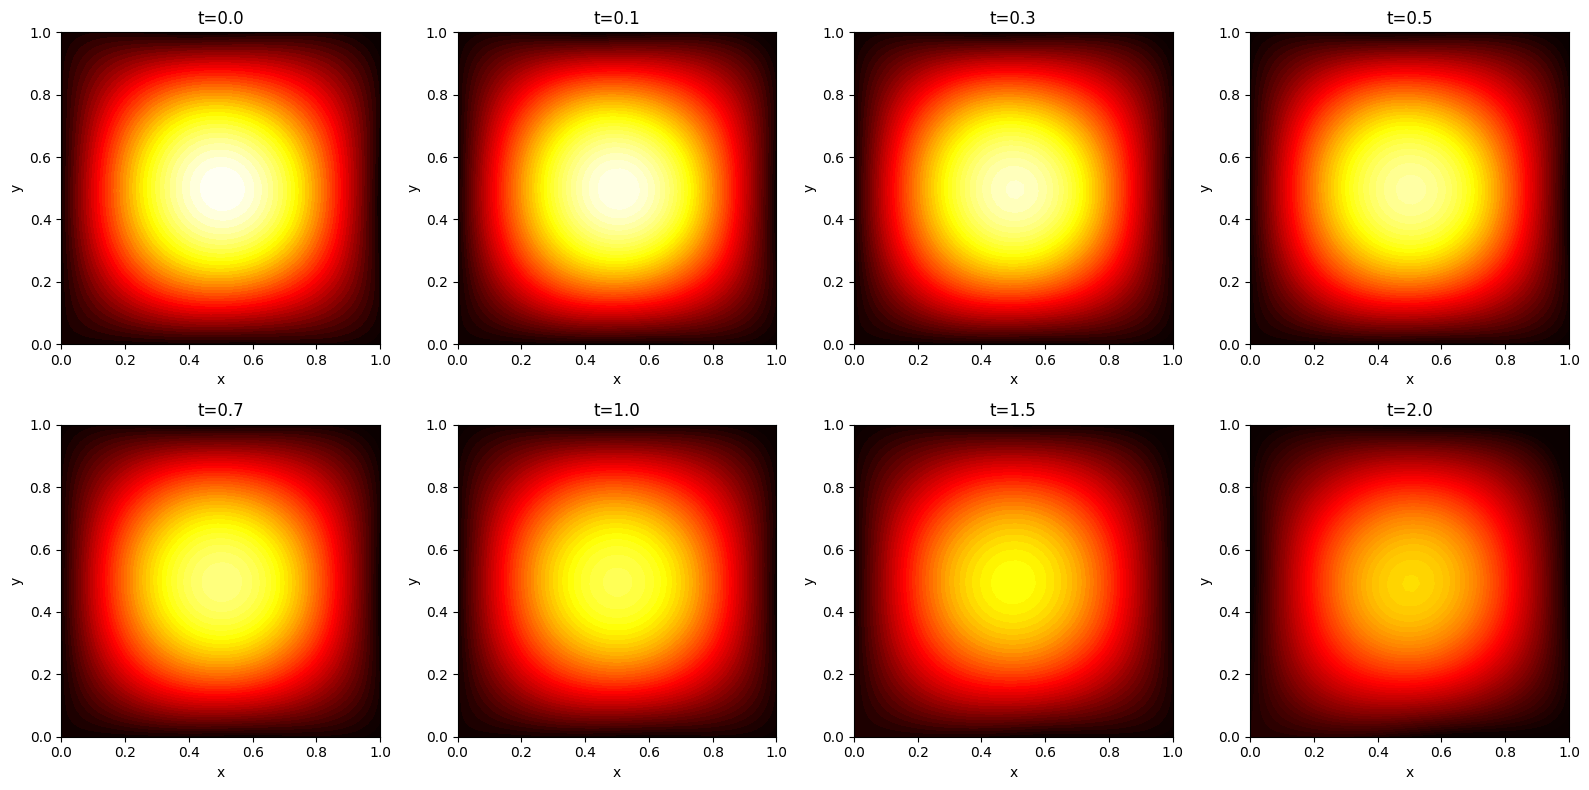

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
zeitpunkte = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

for idx, t_val in enumerate(zeitpunkte):
    t_flat = torch.full((n_grid*n_grid, 1), t_val).to(device)
    inp_plot = torch.cat([x_flat, y_flat, t_flat], dim=1)

    with torch.no_grad():
        u_plot = model(inp_plot).reshape(n_grid, n_grid).cpu().numpy()

    ax = axes[idx // 4][idx % 4]
    ax.contourf(X.numpy(), Y.numpy(), u_plot, levels=50, cmap='hot', vmin=0, vmax=1)
    ax.set_title(f"t={t_val}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("pinn_zeitverlauf.png")
plt.show()

In [ ]:
# PINN